In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import gc
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')
for col in df.select_dtypes('float64').columns: df[col] = df[col].astype('float32')
for col in df.select_dtypes('int64').columns:   df[col] = df[col].astype('int32')
print("Shape:", df.shape)
df.head()

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv
Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.273438,120,704,1863.420044,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.648438,75,438,249.460007,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.320312,82,480,605.590027,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.906250,120,712,700.070007,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.781250,120,661,1226.880005,Estimated (Region),8722


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
Year                      int32
Month                     int32
Region                   object
Model                    object
Estimated_Deliveries      int32
Production_Units          int32
Avg_Price_USD           float32
Battery_Capacity_kWh      int32
Range_km                  int32
CO2_Saved_tons          float32
Source_Type              object
Charging_Stations         int32
dtype: object


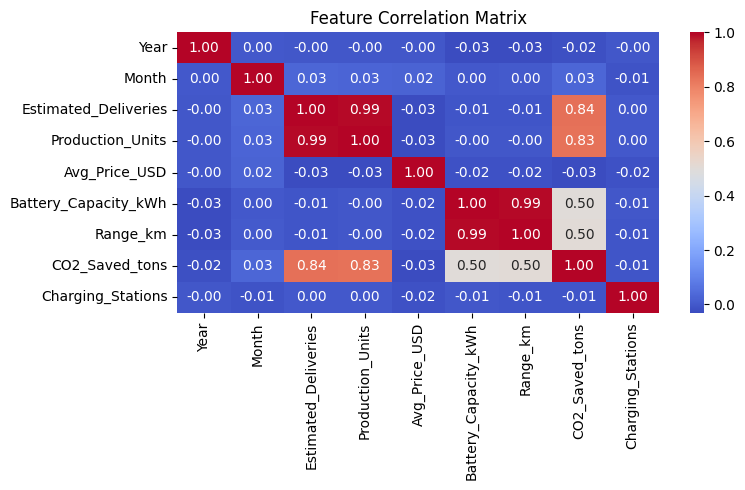

In [4]:
print(df.isnull().sum())
print(df.dtypes)

plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [5]:
df['Timeline_Score'] = (df['Year'] + df['Month'] / 12.0).astype('float32')
df = df.sort_values(['Year', 'Month']).reset_index(drop=True)

X = df.drop(columns=['Estimated_Deliveries'])
y = df['Estimated_Deliveries'].astype('float32')
del df; gc.collect()

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int32', 'float32', 'int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))]), cat_cols)
])
print("Preprocessor ready.")

Preprocessor ready.


In [6]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

rf_pipeline = Pipeline([('pre', preprocessor), ('reg', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))])
xgb_pipeline = Pipeline([('pre', preprocessor), ('reg', XGBRegressor(n_estimators=50, tree_method='hist', random_state=42))])

rf_pipeline.fit(X_train, y_train);  print("RF done")
xgb_pipeline.fit(X_train, y_train); print("XGB done")
gc.collect()

Train: 2112 | Test: 528
RF done
XGB done


68

In [7]:
tscv = TimeSeriesSplit(n_splits=3)

params = {
    'reg__n_estimators':  [50, 100],
    'reg__max_depth':     [3, 5],
    'reg__learning_rate': [0.1, 0.2]
}

search = RandomizedSearchCV(xgb_pipeline, params, n_iter=3, cv=tscv,
                            scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best_model = search.best_estimator_
print("Best params:", search.best_params_)
gc.collect()

Best params: {'reg__n_estimators': 100, 'reg__max_depth': 3, 'reg__learning_rate': 0.2}


71

Random Forest  — MAE: 331.31 | R2: 0.9874
Optimized XGB  — MAE: 304.03 | R2: 0.9898


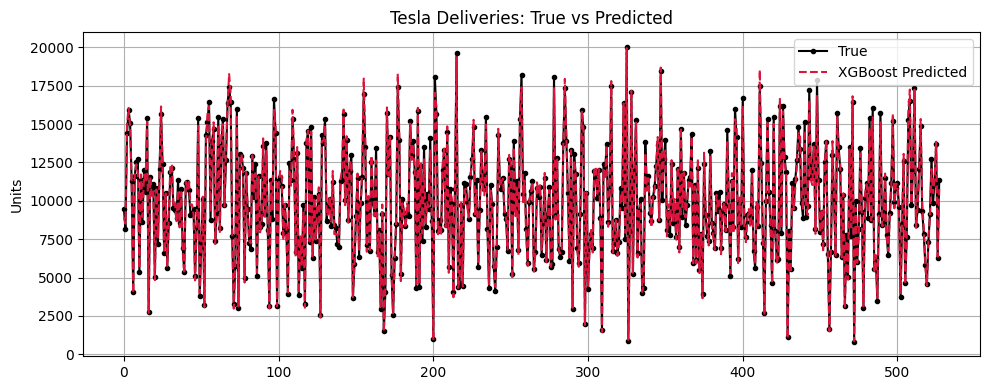

In [8]:
rf_preds  = rf_pipeline.predict(X_test)
xgb_preds = best_model.predict(X_test)

print(f"Random Forest  — MAE: {mean_absolute_error(y_test, rf_preds):.2f} | R2: {r2_score(y_test, rf_preds):.4f}")
print(f"Optimized XGB  — MAE: {mean_absolute_error(y_test, xgb_preds):.2f} | R2: {r2_score(y_test, xgb_preds):.4f}")

plt.figure(figsize=(10, 4))
plt.plot(y_test.values, label="True", color='black', marker='o', markersize=3)
plt.plot(xgb_preds,     label="XGBoost Predicted", color='crimson', linestyle='--')
plt.title("Tesla Deliveries: True vs Predicted")
plt.ylabel("Units")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()